In [1]:
import numpy as np
import math
import pandas as pd
import matplotlib.pyplot as plt

def obtenerEstadisticas(nombreArchivo):
    dataset = pd.read_csv(nombreArchivo)
    # ID,MSE,PSNR_dB,SSIM

    Max_MSE = max(dataset["MSE"])
    Max_SSIM = max(dataset["SSIM"])
    Max_PSNR = max(dataset["PSNR_dB"])
    Min_PSNR = min(dataset["PSNR_dB"])
    Min_MSE = min(dataset["MSE"])
    Min_SSIM = min(dataset["SSIM"])
    Prom_SSIM = dataset["SSIM"].mean()
    Prom_PSNR = dataset["PSNR_dB"].mean()
    Prom_MSE = dataset["MSE"].mean()

    data = {
        'Métrica': ['Promedio', 'Máximo', 'Mínimo'],
        'MSE': [Prom_MSE, Max_MSE, Min_MSE ],
        'PSNR_dB': [Prom_PSNR, Max_PSNR,Min_PSNR ],
        'SSIM': [Prom_SSIM,Max_SSIM,Min_SSIM]
    }
    df_ancho = pd.DataFrame(data)
    print(df_ancho)
    return df_ancho


In [2]:
Continuum100p2 = obtenerEstadisticas("metricas_fba_joaco.csv")

    Métrica       MSE    PSNR_dB      SSIM
0  Promedio  0.001102  30.413012  0.853190
1    Máximo  0.003968  35.570241  0.926563
2    Mínimo  0.000277  24.013839  0.628911


In [3]:
Chromosfera100p2 = obtenerEstadisticas("metricas_fba_benja.csv")

    Métrica       MSE    PSNR_dB      SSIM
0  Promedio  0.003266  27.020555  0.882228
1    Máximo  0.069908  32.203669  0.954140
2    Mínimo  0.000602  11.554720  0.020941


In [4]:
Chromosfera100p1 = obtenerEstadisticas("metricas_fba_joshe.csv")

    Métrica       MSE    PSNR_dB      SSIM
0  Promedio  0.005066  25.700896  0.829689
1    Máximo  0.082219  32.754007  0.945249
2    Mínimo  0.000530  10.850269 -0.011549


In [5]:
Continuum100p1= obtenerEstadisticas("metricas_fba_nayely.csv")

    Métrica       MSE    PSNR_dB      SSIM
0  Promedio  0.001302  29.655192  0.841739
1    Máximo  0.008020  35.825698  0.928395
2    Mínimo  0.000261  20.958198  0.581136


In [6]:
Chromosfera200p = obtenerEstadisticas("metricas_fba_extra.csv")

    Métrica       MSE    PSNR_dB      SSIM
0  Promedio  0.007316  29.274541  0.894087
1    Máximo  0.316298  35.826577  0.961034
2    Mínimo  0.000261   4.999037  0.054365


In [7]:
def crearGraficos(Metrica):
    datasets = ['Chromosfera 100p-1','Chromosfera 100p-2','Chromosfera 200p','Continuum100p-1','Continuum100p-2']

    ssim_min  = [Chromosfera100p1[Metrica][2], 
                 Chromosfera100p2[Metrica][2], 
                 Chromosfera200p[Metrica][2], 
                 Continuum100p1[Metrica][2], 
                 Continuum100p2[Metrica][2]]

    ssim_mean = [Chromosfera100p1[Metrica][0], 
                 Chromosfera100p2[Metrica][0],
                 Chromosfera200p[Metrica][0], 
                 Continuum100p1[Metrica][0], 
                 Continuum100p2[Metrica][0]]
    
    ssim_max  = [Chromosfera100p1[Metrica][1], 
                 Chromosfera100p2[Metrica][1],
                 Chromosfera200p[Metrica][1], 
                 Continuum100p1[Metrica][1], 
                 Continuum100p2[Metrica][1]]

    x = np.arange(len(datasets))
    width = 0.15
    plt.figure(figsize=(10,5))
    bars_min = plt.bar(x - width, ssim_min, width, label='Min')
    bars_mean = plt.bar(x, ssim_mean, width, label='Promedio')
    bars_max = plt.bar(x + width, ssim_max, width, label='Max')
    plt.bar_label(bars_min, fmt='%.4f')
    plt.bar_label(bars_mean, fmt='%.4f')
    plt.bar_label(bars_max, fmt='%.4f')
    if Metrica == "MSE":
        plt.yscale('log')
    plt.xticks(x, datasets)
    plt.ylabel(Metrica)
    plt.title(f"{Metrica} por dataset")
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.show()

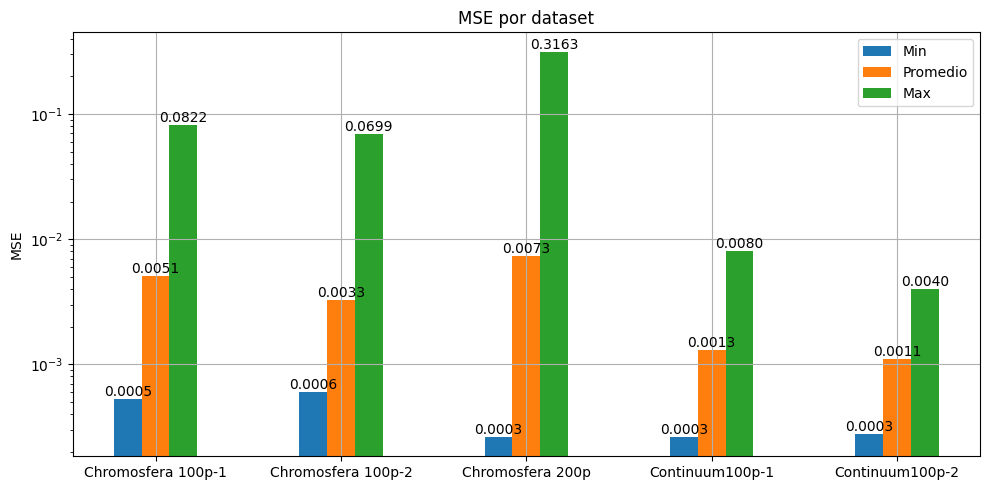

In [8]:
crearGraficos("MSE")

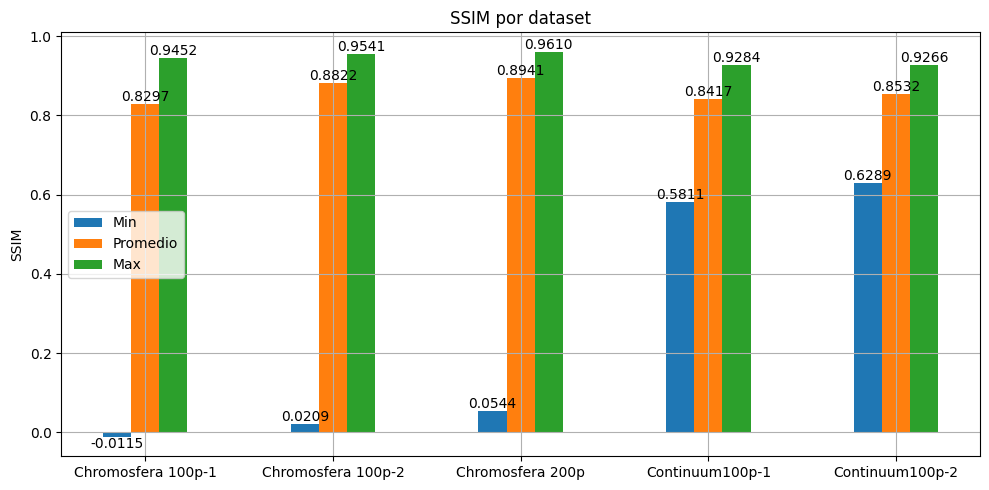

In [9]:
crearGraficos("SSIM")

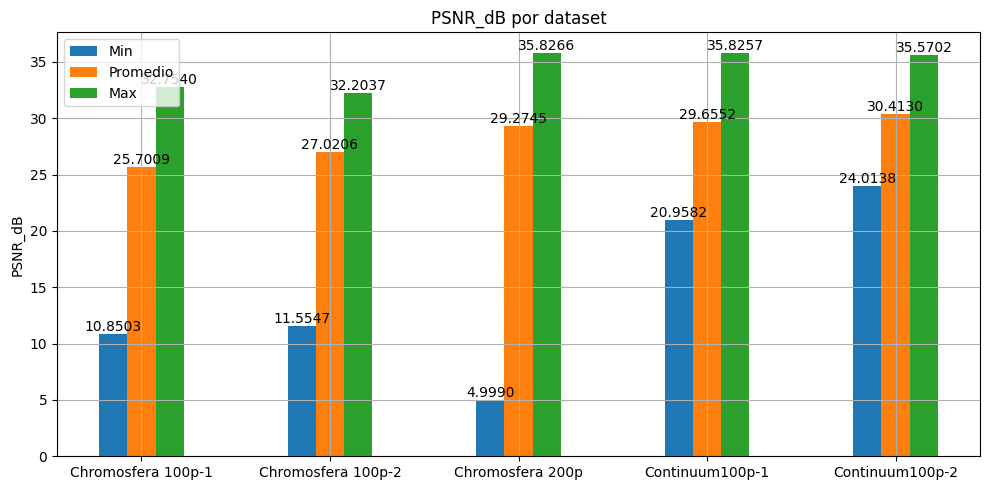

In [10]:
crearGraficos("PSNR_dB")